Regressione lineare in python

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression


In [3]:
# con as_frame=true, ritorna direttamente un df pandas
data = load_diabetes(as_frame=True)
df = data.frame
print(f"Features: {data.feature_names}")
print(df.head())

X = df[data.feature_names]
y = df["target"]

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [4]:
model = LinearRegression()
model.fit(X, y)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [5]:
print(f"Intercetta: {model.intercept_}")
print(f"Feature coefficients:")
for name, coef in zip(data.feature_names, model.coef_):
    print(f"  {name}: {coef:.4f}")

Intercetta: 152.13348416289597
Feature coefficients:
  age: -10.0099
  sex: -239.8156
  bmi: 519.8459
  bp: 324.3846
  s1: -792.1756
  s2: 476.7390
  s3: 101.0433
  s4: 177.0632
  s5: 751.2737
  s6: 67.6267


In [6]:
# label predette con il metodo predict

y_pred = model.predict(X)

In [7]:
# calcolo mae

mae = np.mean(np.abs(y - y_pred))
print(f"Mean Absolute Error: {mae:.3f}")

Mean Absolute Error: 43.277


In [8]:
# alternativamente possiamo verificare la tolleranza

toll = 0.5
good_pred = np.mean(np.abs(y - y_pred) < toll)
print(f"Percentage Good Predictions (MAE < {toll}): {good_pred:.2%}")

Percentage Good Predictions (MAE < 0.5): 0.90%


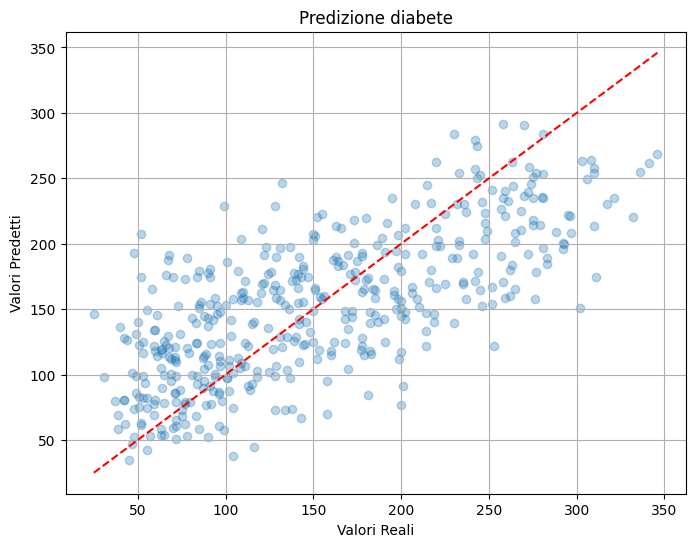

In [10]:
# rappresentazione grafica

plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], color="red", linestyle="--")  # linea di regressione
plt.xlabel("Valori Reali")
plt.ylabel("Valori Predetti")
plt.title("Predizione diabete")
plt.grid()
plt.show()

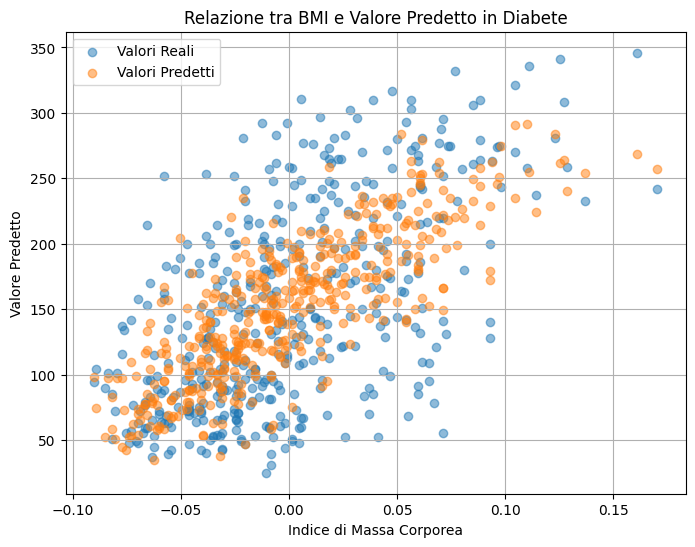

In [11]:
# plot per vedere valore medio del reddito e delle abitazioni (ipotesi più sensata)

plt.figure(figsize=(8, 6))
plt.scatter(df["bmi"], df["target"], alpha=0.5, label="Valori Reali")
plt.scatter(df["bmi"], y_pred, alpha=0.5, label="Valori Predetti")
plt.xlabel("Indice di Massa Corporea")
plt.ylabel("Valore Predetto")
plt.title("Relazione tra BMI e Valore Predetto in Diabete")
plt.legend()
plt.grid()
plt.show()

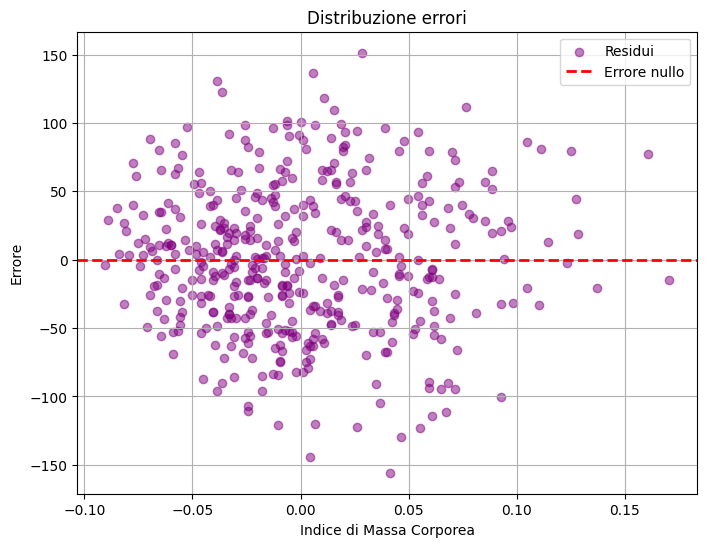

In [12]:
# rappresentazione grafica errore in base al medInc

error = y.squeeze() - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(X["bmi"], error, color="purple", alpha=0.5, label="Residui")
plt.axhline(y = 0, color="red", linestyle="--", linewidth=2, label="Errore nullo")
plt.xlabel("Indice di Massa Corporea")
plt.ylabel("Errore")
plt.title("Distribuzione errori")
plt.legend()
plt.grid()
plt.show()